1) Importing and checking data step

In [2]:
#Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Import/read data from CSV and check head and tail of file to ensure it is displayed correctly.
df = pd.read_csv('/content/NetFlix.csv')
display(df.head())
display(df.tail())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,6-Dec-16,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...


In [5]:
# Display information about dataset
display(df.shape)
display(df.info())

(7787, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


None

2) Clean dataset

In [6]:
# Identify and quantify missing values as count and %.
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing Values Information:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))


Missing Values Information:
            Missing Count  Missing Percentage
director             2389           30.679337
cast                  718            9.220496
country               507            6.510851
date_added             10            0.128419
rating                  7            0.089893


In [7]:
# Replace unknown information with "Unknown", back/forward fill not suitable methods.
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
print("Missing values in 'director', 'cast', and 'country' filled with 'Unknown'.")

# Drop rows with missing 'date_added' or 'rating' values due to small amount of results.
df.dropna(subset=['date_added', 'rating'], inplace=True)
print("Rows with missing 'date_added' or 'rating' values dropped.")

# Verify no more missing values.
print("\nVerifying remaining missing values:")
print(df.isnull().sum())

Missing values in 'director', 'cast', and 'country' filled with 'Unknown'.
Rows with missing 'date_added' or 'rating' values dropped.

Verifying remaining missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64


In [8]:
# Check for and remove duplicates.
print(f"Number of duplicate rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Updated number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0
Updated number of duplicate rows: 0


In [9]:
# Convert dates to correct date type using understandable format (yyyy/mm/dd) (standard for dateframe).
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print("Converted 'date_added' column to datetime objects.")

df.info()

Converted 'date_added' column to datetime objects.
<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   int64         
 10  genres        7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 789.1+ KB


/tmp/ipykernel_269/219752242.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


3) Visualise data

a) What are the most common genres?


In [10]:
# Identify most common genres.
# Split string where more than one genre is present.
genres_split = df['genres'].str.split(', ').explode()
top_5_genres = genres_split.value_counts().head(5)
print("Top 5 most frequent genres:")
print(top_5_genres)

Top 5 most frequent genres:
genres
International Movies      2437
Dramas                    2105
Comedies                  1471
International TV Shows    1197
Documentaries              786
Name: count, dtype: int64


In [11]:
top_5_genre_names = top_5_genres.index.tolist()

# Function to check if any genre in a string is in the top 5 list
def contains_top_genre(genre_string, top_genres_list):
    if pd.isna(genre_string):
        return False
    genres_in_row = [g.strip() for g in genre_string.split(',')]
    return any(g in top_genres_list for g in genres_in_row)

# Filter the original DataFrame to keep rows where 'genres' contains at least one of the top 5 genres
df_filtered = df[df['genres'].apply(lambda x: contains_top_genre(x, top_5_genre_names))]

# Split and explode the 'genres' column for the filtered DataFrame
df_exploded_genres = df_filtered.assign(genres=df_filtered['genres'].str.split(', ')).explode('genres')

# Filter the exploded data to only include the genres that are in the top 5 list
df_final_genres = df_exploded_genres[df_exploded_genres['genres'].isin(top_5_genre_names)]

# Group by 'genres' and 'type' and count occurrences
genre_type_counts = df_final_genres.groupby(['genres', 'type']).size().reset_index(name='count')

print("Prepared data for clustered bar chart:")
display(genre_type_counts.head())

Prepared data for clustered bar chart:


,genres,type,count
0,Comedies,Movie,1471
1,Documentaries,Movie,786
2,Dramas,Movie,2105
3,International Movies,Movie,2437
4,International TV Shows,TV Show,1197


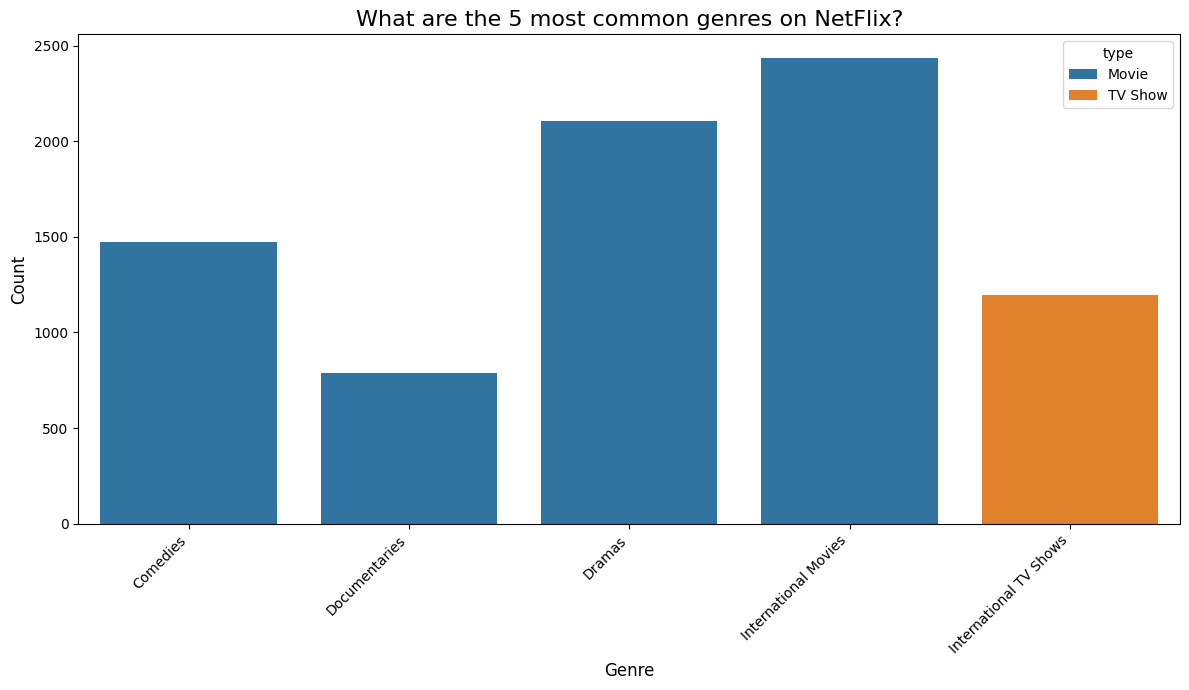

In [15]:
# Create the bar chart
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability
sns.barplot(x='genres', y='count', hue='type', data=genre_type_counts)

# Add title and labels
plt.title('What are the 5 most common genres on NetFlix?', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


b) Has there been a change in release format in the past 20 years?


In [20]:
# Count instances grouped by release year and genres.
yearly_counts = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
yearly_counts = yearly_counts.reset_index()

# Filter for release years from 2006 onwards
yearly_counts = yearly_counts[yearly_counts['release_year'] >= 2006]

print("Prepared data for stacked column chart (yearly_counts) from 2006 onwards:")
display(yearly_counts.head())

Prepared data for stacked column chart (yearly_counts) from 2006 onwards:


type,release_year,Movie,TV Show
57,2006,72,13
58,2007,72,13
59,2008,102,22
60,2009,103,34
61,2010,135,36


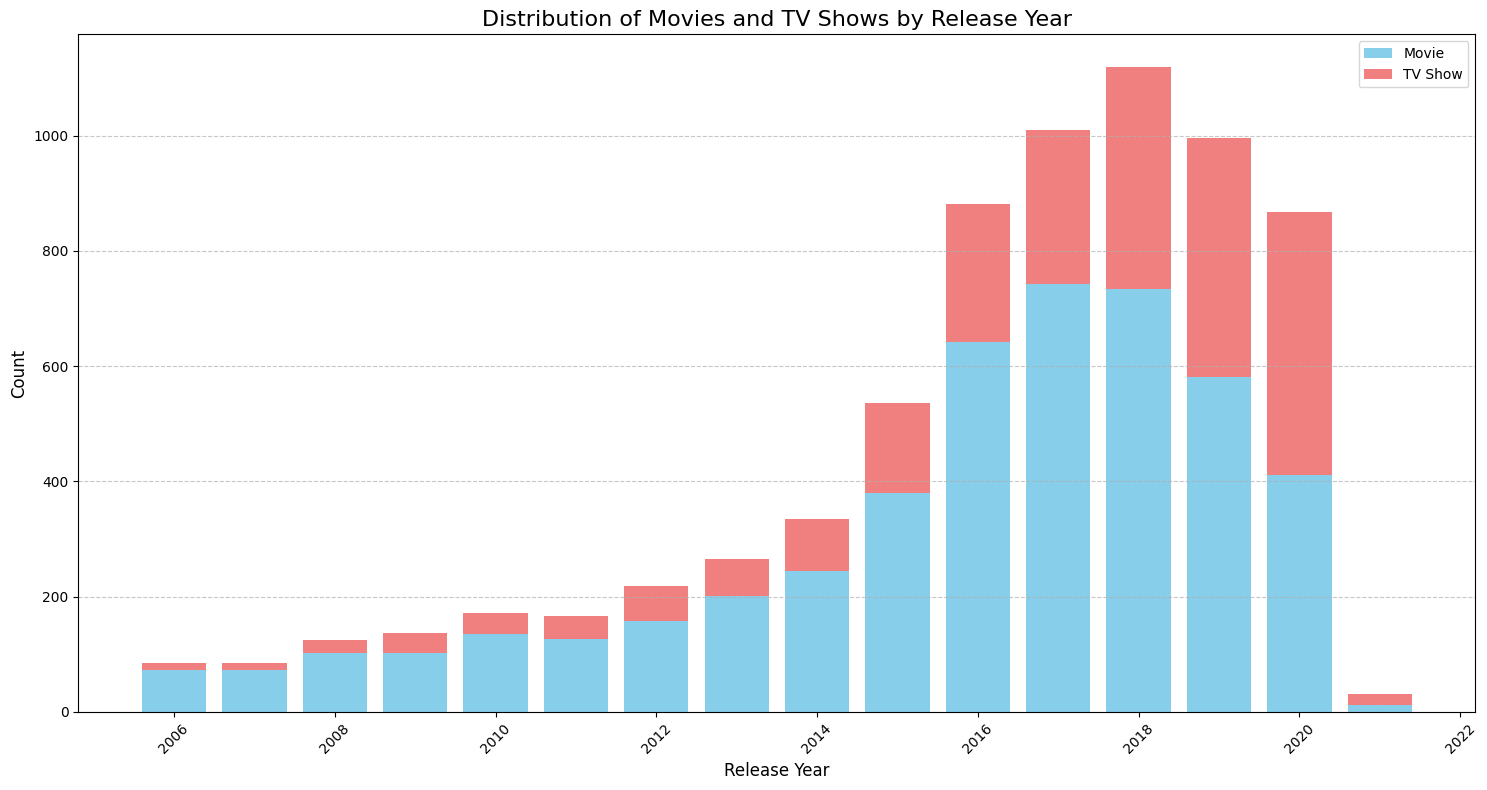

In [21]:

# Create bars for movies
plt.figure(figsize=(15, 8))
plt.bar(yearly_counts['release_year'], yearly_counts['Movie'], label='Movie', color='skyblue')
# Create bar for TV shows and stack on top of movie.
plt.bar(yearly_counts['release_year'], yearly_counts['TV Show'], bottom=yearly_counts['Movie'], label='TV Show', color='lightcoral')

# Formatting
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Movies and TV Shows by Release Year', fontsize=16)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

c) Is there a trend in the average movie length by year?

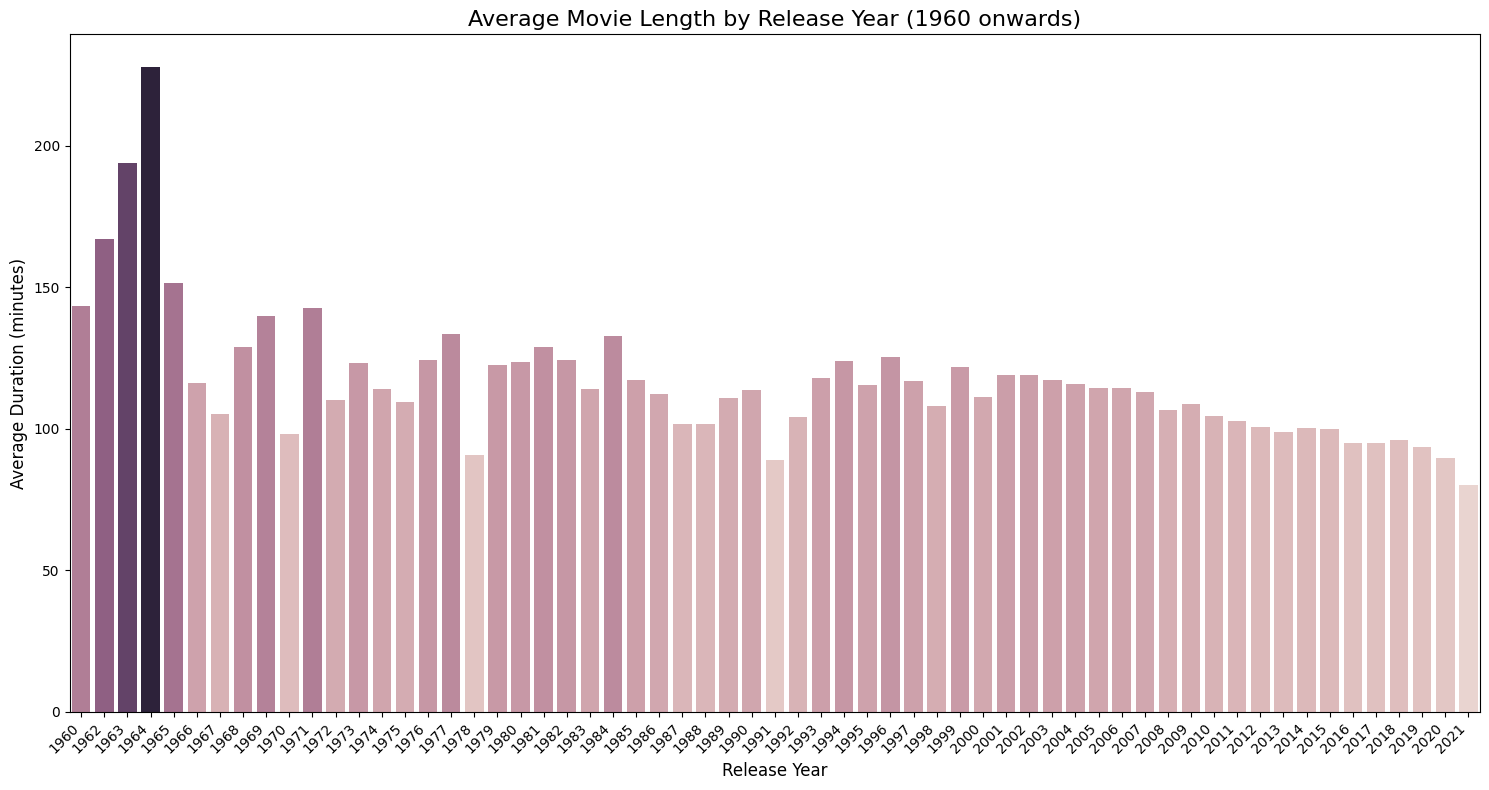

In [27]:
# Filter the DataFrame for only movies to get average_movie_length_by_year
movies_df = df[df['type'] == 'Movie']
average_movie_length_by_year = movies_df.groupby('release_year')['duration'].mean().reset_index()

# Filter for release years from 1960 onwards
average_movie_length_by_year_filtered = average_movie_length_by_year[average_movie_length_by_year['release_year'] >= 1960]

# Create the column chart
plt.figure(figsize=(15, 8))
sns.barplot(x='release_year', y='duration', data=average_movie_length_by_year_filtered, hue='duration', legend=False)

# Add title and labels
plt.title('Average Movie Length by Release Year (1960 onwards)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Average Duration (minutes)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()